# Тестовое задание: аналитик, команда Business Travel

Данные: 1964 бронирования за 2025 год и справочник по 50 корпоративным клиентам.
GMV везде считаю как сумму `amount_rub` по бронированиям со статусом `confirmed`.

Перед анализом бегло проверил данные: пропусков нет, дублей `booking_id` нет, отрицательных
сумм нет, все `client_id` из бронирований есть в справочнике. Одна деталь всплыла сразу и
влияет на задание 6 — `first_booking_date` у всех 50 клиентов приходится на 2024 год, в 2025
ни одного нового клиента. Поэтому когорты строю по месяцу первой активности клиента в 2025
(фактически это retention уже существующей базы). Ниже по порядку заданий.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.grid': True,
                     'grid.alpha': .3, 'axes.spines.top': False, 'axes.spines.right': False})
PAL = {'avia': '#2563eb', 'hotel': '#f59e0b', 'train': '#10b981', 'taxi': '#ef4444'}

bookings = pd.read_csv('data/bookings.csv')
clients = pd.read_csv('data/clients.csv')
for col in ['booking_date', 'trip_date']:
    bookings[col] = pd.to_datetime(bookings[col])
clients['first_booking_date'] = pd.to_datetime(clients['first_booking_date'])

bookings['month'] = bookings['booking_date'].dt.to_period('M')
df = bookings.merge(clients[['client_id', 'company_name', 'tier', 'industry']], on='client_id', how='left')
conf = df[df.status == 'confirmed'].copy()   # confirmed = то, что идёт в GMV

print(f"Всего бронирований: {len(df)}, из них confirmed: {len(conf)}")
print(f"Клиентов: {df.client_id.nunique()}, GMV за год: {conf.amount_rub.sum()/1e6:.1f} млн руб.")

Всего бронирований: 1964, из них confirmed: 1691
Клиентов: 50, GMV за год: 84.7 млн руб.


## Задание 1. GMV и число бронирований по субпродуктам, помесячно

In [2]:
# помесячный GMV в разрезе субпродуктов
gmv_month = (conf.pivot_table(index='month', columns='subproduct',
             values='amount_rub', aggfunc='sum', fill_value=0) / 1e6).round(2)
gmv_month['итого'] = gmv_month.sum(axis=1)
print("GMV по месяцам, млн руб.")
print(gmv_month)

# итоги за год по субпродуктам
by_sub = conf.groupby('subproduct').agg(
    gmv_млн=('amount_rub', lambda s: round(s.sum()/1e6, 1)),
    бронирований=('booking_id', 'count'),
    средний_чек=('amount_rub', lambda s: round(s.mean())))
by_sub['доля_gmv_%'] = (by_sub.gmv_млн / by_sub.gmv_млн.sum() * 100).round(1)
print()
print(by_sub.sort_values('gmv_млн', ascending=False))

GMV по месяцам, млн руб.
subproduct  avia  hotel  taxi  train  итого
month                                      
2025-01     3.47   1.66  0.02   0.40   5.55
2025-02     4.82   2.28  0.03   0.33   7.46
2025-03     5.97   2.75  0.05   0.54   9.31
2025-04     4.55   2.71  0.04   0.52   7.82
2025-05     4.62   3.05  0.04   0.39   8.10
2025-06     7.47   3.48  0.05   0.64  11.64
2025-07     4.64   2.73  0.03   0.32   7.72
2025-08     3.67   3.24  0.02   0.43   7.36
2025-09     2.92   2.22  0.03   0.23   5.40
2025-10     3.07   1.76  0.02   0.25   5.10
2025-11     3.50   1.32  0.02   0.21   5.05
2025-12     2.62   1.29  0.02   0.27   4.20

            gmv_млн  бронирований  средний_чек  доля_gmv_%
subproduct                                                
avia           51.3           650        78932        60.6
hotel          28.5           540        52769        33.6
train           4.5           327        13866         5.3
taxi            0.4           174         2110         0.5


Больше всего оборота даёт **avia — 51.3 млн руб., это 61% GMV**, следом hotel (33%). Train и taxi
вместе меньше 6%: у такси при 174 поездках средний чек всего около 2 тыс. руб., так что для оборота
это скорее сопутствующий продукт. По сути весь бизнес — это перелёты и отели.

По сезонности: календарного сезона как такого не видно, но есть чёткий тренд внутри года. GMV растёт
до пика в июне (11.7 млн) и дальше почти монотонно падает до минимума в декабре (4.2 млн), то есть
первое полугодие (49.9 млн) заметно сильнее второго (34.8 млн). Причём это не сезонный провал —
в задании 5 видно, что во втором полугодии просто ушла часть клиентов.

## Задание 2. Топ-10 клиентов по GMV

In [3]:
top10 = (conf.groupby(['client_id', 'company_name', 'tier', 'industry'])
         .agg(gmv=('amount_rub', 'sum'), бронирований=('booking_id', 'count')))
top10['средний_чек'] = (top10.gmv / top10.бронирований).round()
top10 = top10.sort_values('gmv', ascending=False).head(10)

out = top10.reset_index()[['company_name', 'tier', 'industry', 'gmv', 'бронирований', 'средний_чек']].copy()
out['gmv'] = (out.gmv / 1e6).round(2).astype(str) + ' млн'
print(out.to_string(index=False))
print(f"\nДоля топ-10 в общем GMV: {top10.gmv.sum() / conf.amount_rub.sum() * 100:.0f}%")

 company_name  tier      industry       gmv  бронирований  средний_чек
ГаммаЭкспресс     1            IT 10.56 млн           131      80636.0
  ПсиЦифровой     1            IT  9.22 млн           115      80202.0
ТауКонсалтинг     1 Строительство   8.0 млн            98      81630.0
    ЮгКомпани     1 Строительство  7.24 млн            83      87266.0
   АльфаГрупп     2       Финансы  3.62 млн            70      51694.0
  ЦентрАльянс     2     Логистика  2.91 млн            60      48497.0
       РоАгро     2     Логистика  2.84 млн            63      45073.0
       ФиАвто     2       Финансы  2.73 млн            64      42727.0
 СтандартХолд     2        Ритейл  2.65 млн            62      42740.0
 ДельтаФинанс     2     Логистика  2.62 млн            53      49372.0

Доля топ-10 в общем GMV: 62%


Топ-10 клиентов дают примерно 62% всего оборота — концентрация высокая. Первые четыре места — все
клиенты тира 1 (ГаммаЭкспресс, ПсиЦифровой, ТауКонсалтинг, ЮгКомпани), у каждого 7–10.5 млн руб. и
средний чек порядка 80–87 тыс. Дальше идут клиенты тира 2. Отдельно отмечу СтандартХолд на 9-м месте:
крупный клиент с 2.6 млн, который во втором полугодии перестал бронировать (попадёт в отток, задание 5).

## Задание 3. Доля отмен по субпродуктам

In [4]:
cancel = df.groupby('subproduct').agg(
    всего=('booking_id', 'count'),
    отмен=('status', lambda s: (s == 'cancelled').sum()))
cancel['доля_отмен_%'] = (cancel.отмен / cancel.всего * 100).round(1)
print(cancel.sort_values('доля_отмен_%', ascending=False))
print(f"\nВ среднем по всем: {(df.status == 'cancelled').mean() * 100:.1f}%")

# заодно проверил очевидную гипотезу — вдруг отменяют то, что бронируют сильно заранее
df['lead'] = (df.trip_date - df.booking_date).dt.days
print("\nМедианный горизонт брони (дней), confirmed vs cancelled:")
print(df.groupby(['subproduct', 'status']).lead.median().unstack().round(0))

            всего  отмен  доля_отмен_%
subproduct                            
avia          767    117          15.3
train         379     52          13.7
hotel         623     83          13.3
taxi          195     21          10.8

В среднем по всем: 13.9%

Медианный горизонт брони (дней), confirmed vs cancelled:
status      cancelled  confirmed
subproduct                      
avia             11.0       11.0
hotel            10.0       12.0
taxi             11.0       12.0
train            11.0       11.0


Средняя доля отмен около 14%. Заметно выше остальных — avia (15.3%), ниже всех — taxi (10.8%).
Разброс небольшой (около 4.5 п.п.), так что сильных выводов делать не стал бы.

Первую напрашивающуюся гипотезу — «отменяют то, что бронируют сильно заранее» — проверил и она не
подтвердилась: горизонт брони везде примерно одинаковый (11–12 дней) и у подтверждённых, и у отменённых.
Более правдоподобное объяснение: avia — самый дорогой и самый «планозависимый» продукт. Билет привязан
к расписанию и к конкретной встрече, и при переносе или отмене всей поездки первым отменяется именно он.
Taxi наоборот — дешёвый last-mile, его заказывают в последний момент, поэтому и отменяют реже. Чтобы
проверить, стоит посмотреть, отменяется ли avia в связке со всей поездкой (avia + hotel одного клиента
на одну дату) — это отделит отмену планов от простой смены билета.

## Задание 4. Гипотеза про тиры

Гипотеза: клиенты тира 1 бронируют более дорогие продукты, но реже, чем клиенты тира 3.

In [5]:
tier = conf.groupby('tier').agg(
    gmv=('amount_rub', 'sum'),
    бронирований=('booking_id', 'count'),
    средний_чек=('amount_rub', 'mean'))
tier['клиентов'] = clients.groupby('tier').client_id.nunique()
tier['бронир_на_клиента'] = (tier.бронирований / tier.клиентов).round(1)
tier['gmv_на_клиента_тыс'] = (tier.gmv / tier.клиентов / 1e3).round()
tier['средний_чек'] = tier.средний_чек.round()
tier['gmv_млн'] = (tier.gmv / 1e6).round(1)
print(tier[['клиентов', 'средний_чек', 'бронир_на_клиента', 'gmv_млн', 'gmv_на_клиента_тыс']])

      клиентов  средний_чек  бронир_на_клиента  gmv_млн  gmv_на_клиента_тыс
tier                                                                       
1            4      82036.0              106.8     35.0              8757.0
2           16      44729.0               52.0     37.2              2326.0
3           30      28839.0               14.4     12.5               415.0


Гипотеза подтвердилась только наполовину. Про «дороже» — да: средний чек тира 1 около 82 тыс. против
29 тыс. у тира 3, разница почти в три раза. А вот про «реже» — наоборот: тир 1 бронирует ~107 раз на
клиента, тир 3 — всего ~14. То есть крупный клиент и дороже, и намного активнее.

Что ещё бросается в глаза: экономика на клиента различается радикально. Тир 1 приносит ~8.8 млн руб. с
клиента, тир 3 — 0.4 млн, разница в 21 раз. И всего 4 клиента тира 1 (8% базы) дают 41% всего GMV. Это,
на мой взгляд, главный риск сервиса — он держится на нескольких крупных клиентах, и потеря даже одного
из них стоит несколько миллионов оборота.

## Задание 5. Отток: были в первом полугодии, ничего подтверждённого во втором

In [6]:
h1_clients = set(df[(df.booking_date >= '2025-01-01') & (df.booking_date <= '2025-06-30')].client_id)
h2_confirmed = set(conf[conf.booking_date >= '2025-07-01'].client_id)
churn = sorted(h1_clients - h2_confirmed)

churned = clients[clients.client_id.isin(churn)]
h1_gmv = conf[(conf.booking_date <= '2025-06-30') & (conf.client_id.isin(churn))].amount_rub.sum()
h1_total = conf[conf.booking_date <= '2025-06-30'].amount_rub.sum()
# заодно проверил — есть ли у них в H2 хоть какие-то бронирования, пусть отменённые
h2_any = df[(df.booking_date >= '2025-07-01') & (df.client_id.isin(churn))].shape[0]

print(f"Активных в H1: {len(h1_clients)}, из них ушло в H2: {len(churn)}")
print(f"Их GMV за H1: {h1_gmv/1e6:.1f} млн руб. ({h1_gmv/h1_total*100:.0f}% от GMV первого полугодия)")
print(f"По тирам: {churned.tier.value_counts().sort_index().to_dict()}")
print(f"Бронирований у них в H2 (любой статус): {h2_any}")
print()
print(churned[['client_id', 'company_name', 'tier', 'industry']].to_string(index=False))

Активных в H1: 50, из них ушло в H2: 16
Их GMV за H1: 17.5 млн руб. (35% от GMV первого полугодия)
По тирам: {2: 6, 3: 10}
Бронирований у них в H2 (любой статус): 0

 client_id   company_name  tier      industry
        35       НордВест     3     Логистика
        36      ТехноПром     3        Ритейл
        37      МегаСтрой     2     Логистика
        38 УниверсалГрупп     3            IT
        39    ПартнёрПлюс     3        Ритейл
        40    ТрастСервис     3            IT
        41       КвантТех     3        Ритейл
        42      СинтезПро     3 Строительство
        43    АктивБизнес     3        Ритейл
        44 ПрогрессИнвест     3 Строительство
        45   СтандартХолд     2        Ритейл
        46       НоваяЭра     2     Логистика
        47   ВершинаГрупп     2        Ритейл
        48    АтлантТрейд     2            IT
        49      ПрофиЛайн     2     Логистика
        50      ЭкспертКо     3     Логистика


Ушло 16 клиентов — это треть всей базы. Их суммарный GMV за первое полугодие 17.5 млн руб., то есть
35% оборота H1, сумма серьёзная. Все они тира 2 (6 клиентов) и тира 3 (10), ни одного тира 1 — ядро
клиентов удержалось.

Причём отток полный, а не «перестали подтверждать»: во втором полугодии у этих клиентов ноль бронирований
вообще, любого статуса. Именно они, а не сезонность, роняют GMV во втором полугодии из задания 1. По
списку это ровно клиенты с id 35–50 — идущие подряд, что немного похоже на то, как собран датасет, но
бизнес-смысл от этого не меняется: во второй половине года отвалился весь средний и малый сегмент, и
разобраться с этим я бы поставил первым приоритетом.

## Задание 6. Когортный анализ

Как отметил в начале, `first_booking_date` у всех клиентов в 2024 году, так что «новых клиентов 2025» по
строгому определению ноль. Чтобы задание имело смысл, беру за когорту месяц первой активности клиента
в 2025 году и смотрю, какая доля когорты делала хотя бы одно `confirmed` бронирование в каждом следующем
месяце.

In [7]:
print("Клиентов с first_booking_date в 2025 году:", (clients.first_booking_date.dt.year == 2025).sum())

first_activity = conf.groupby('client_id').month.min().rename('cohort')
c2 = conf.merge(first_activity, on='client_id')
all_months = sorted(conf.month.unique())

rows = []
for coh in sorted(c2.cohort.unique()):
    sub = c2[c2.cohort == coh]
    base = sub.client_id.nunique()
    row = {'когорта': str(coh), 'клиентов': base}
    for i, m in enumerate([mm for mm in all_months if mm >= coh]):
        row[f'M{i}'] = round(sub[sub.month == m].client_id.nunique() / base * 100)
    rows.append(row)

retention = pd.DataFrame(rows).set_index('когорта')
print("\nRetention, % активных клиентов когорты по месяцам:")
print(retention.to_string())

Клиентов с first_booking_date в 2025 году: 0

Retention, % активных клиентов когорты по месяцам:
         клиентов   M0  M1   M2  M3  M4  M5   M6   M7  M8  M9   M10   M11
когорта                                                                  
2025-01        36  100  83   89  89  92  92   64   58  56  56  47.0  50.0
2025-02        10  100  90   60  90  90  50   60   40  40  30  60.0   NaN
2025-03         4  100   0  100  50  50  75  100  100  50  50   NaN   NaN


Почти все клиенты (36 из 50) стартуют в январе — логично, раз базу набрали ещё в 2024-м. Январская
когорта держится хорошо, на уровне 83–92%, вплоть до июня, а с седьмого месяца (июль) удержание резко
падает до 64%, потом до 58% и ниже, к концу года около половины. Это та же граница между полугодиями,
что и в оттоке. Каких-то когорт, которые удерживаются заметно лучше остальных, не видно — динамику
определяет не месяц входа, а общий разрыв между первым и вторым полугодием. Февральская и мартовская
когорты слишком маленькие (4–10 клиентов), там цифры шумные и я бы на них не опирался.

## Задание 7. Графики

Собрал пять графиков, под каждым — почему выбрал такой тип и разрез.

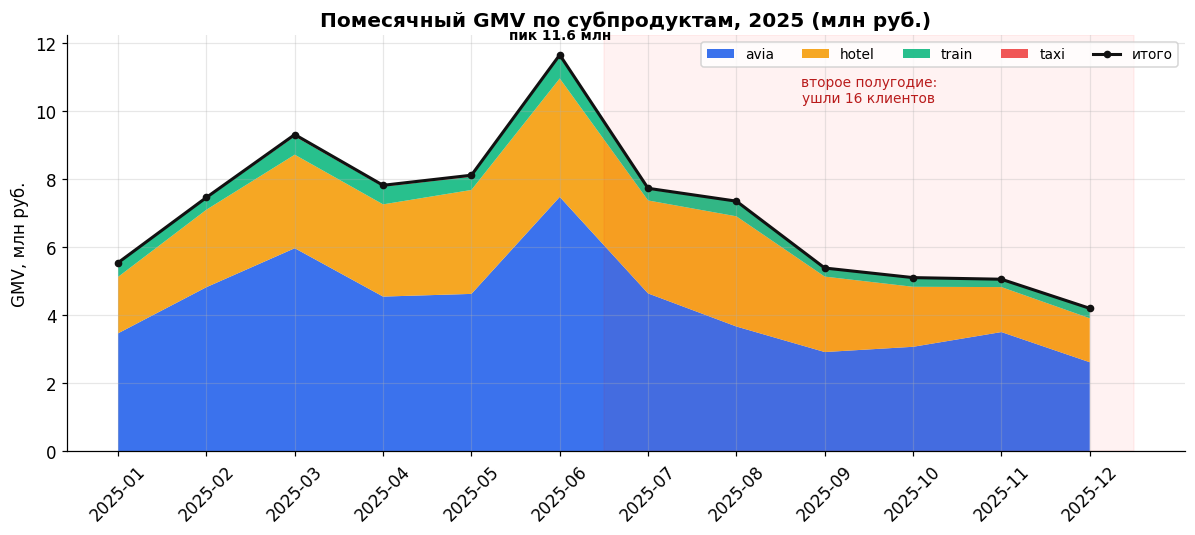

In [8]:
# 1. Помесячный GMV по субпродуктам. Главный график, показывает динамику за год.
fig, ax = plt.subplots(figsize=(11, 5))
pg = conf.pivot_table(index='month', columns='subproduct', values='amount_rub', aggfunc='sum', fill_value=0) / 1e6
x = [str(p) for p in pg.index]
order = ['avia', 'hotel', 'train', 'taxi']
ax.stackplot(x, [pg[s] for s in order], labels=order, colors=[PAL[s] for s in order], alpha=.9)
total = pg.sum(axis=1)
ax.plot(x, total.values, color='#111', lw=2, marker='o', ms=4, label='итого')
ax.annotate(f'пик {total.max():.1f} млн', (x[total.values.argmax()], total.max()),
            textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
ax.axvspan(5.5, 11.5, color='red', alpha=.05)
ax.text(8.5, total.max() * 0.88, 'второе полугодие:\nушли 16 клиентов', ha='center', fontsize=9, color='#b91c1c')
ax.set_title('Помесячный GMV по субпродуктам, 2025 (млн руб.)', fontweight='bold')
ax.set_ylabel('GMV, млн руб.')
ax.legend(loc='upper right', ncol=5, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/1_gmv_monthly.png', bbox_inches='tight')
plt.show()

Взял stacked area по месяцам, потому что он сразу показывает и общий тренд года (чёрная линия «итого»
с пиком в июне и спадом во втором полугодии), и вклад каждого субпродукта — видно, что почти весь оборот
это avia и hotel. Разрез «месяц × субпродукт» здесь самый информативный для вопроса про динамику.

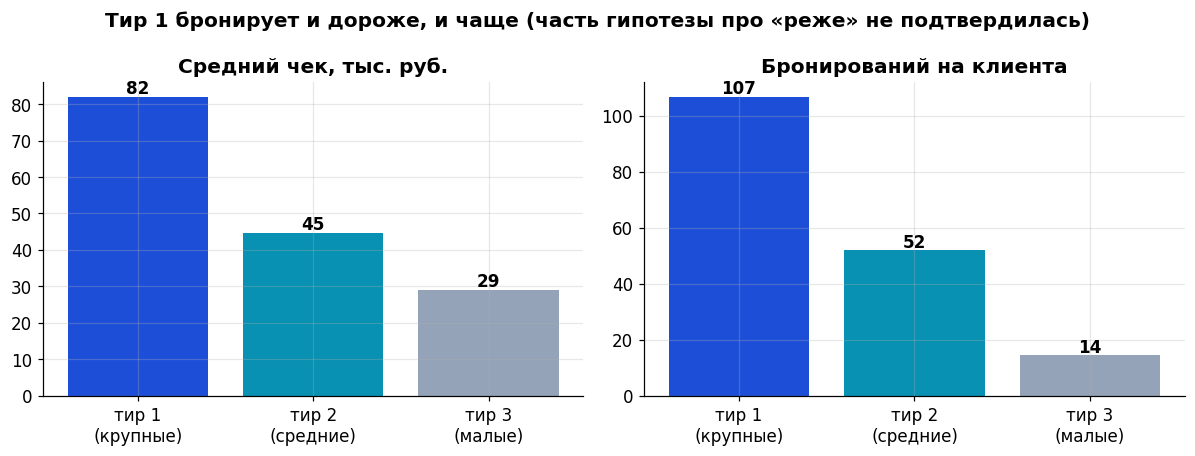

In [9]:
# 2. Экономика тиров: средний чек и число бронирований на клиента
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
t = conf.groupby('tier').agg(chk=('amount_rub', 'mean'), n=('booking_id', 'count'))
t['cl'] = clients.groupby('tier').client_id.nunique()
t['bpc'] = t.n / t.cl
labels = ['тир 1\n(крупные)', 'тир 2\n(средние)', 'тир 3\n(малые)']
cols = ['#1d4ed8', '#0891b2', '#94a3b8']
axes[0].bar(labels, t.chk / 1e3, color=cols)
axes[0].set_title('Средний чек, тыс. руб.', fontweight='bold')
for i, v in enumerate(t.chk / 1e3):
    axes[0].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')
axes[1].bar(labels, t.bpc, color=cols)
axes[1].set_title('Бронирований на клиента', fontweight='bold')
for i, v in enumerate(t.bpc):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')
plt.suptitle('Тир 1 бронирует и дороже, и чаще (часть гипотезы про «реже» не подтвердилась)', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/2_tier_economics.png', bbox_inches='tight')
plt.show()

Две простые столбчатые диаграммы рядом — самый прямой способ показать результат по гипотезе из
задания 4: слева чек растёт от тира 3 к тиру 1, справа в ту же сторону растёт частота. Ровно две метрики,
про которые и была гипотеза.

/var/folders/2d/zjtj67pj61x8ztp_76b6hg5r0000gn/T/ipykernel_23930/3862829187.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cr = df.groupby('subproduct').apply(lambda g: (g.status == 'cancelled').mean() * 100).sort_values()


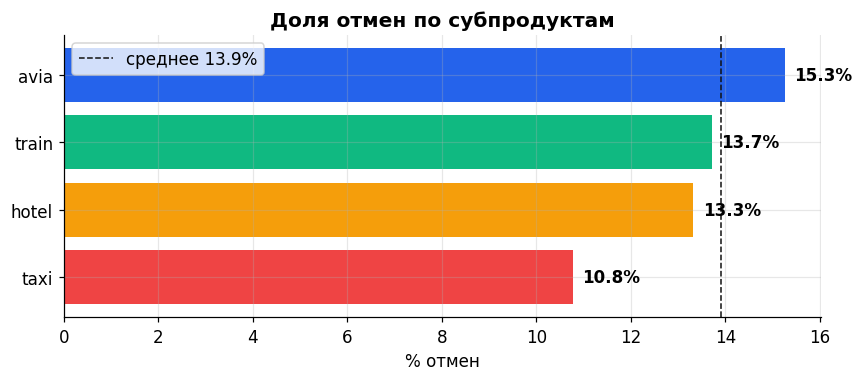

In [10]:
# 3. Доля отмен по субпродуктам
fig, ax = plt.subplots(figsize=(8, 3.6))
cr = df.groupby('subproduct').apply(lambda g: (g.status == 'cancelled').mean() * 100).sort_values()
ax.barh(cr.index, cr.values, color=[PAL[s] for s in cr.index])
for i, (s, v) in enumerate(cr.items()):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')
ax.axvline((df.status == 'cancelled').mean() * 100, color='#111', ls='--', lw=1, label='среднее 13.9%')
ax.set_title('Доля отмен по субпродуктам', fontweight='bold')
ax.set_xlabel('% отмен')
ax.legend()
plt.tight_layout()
plt.savefig('charts/3_cancel_rate.png', bbox_inches='tight')
plt.show()

Горизонтальные бары, отсортированные по значению, — сразу понятно, что avia отменяют чаще, а taxi
реже. Пунктир среднего даёт точку отсчёта, чтобы видеть, кто выше и ниже базы.

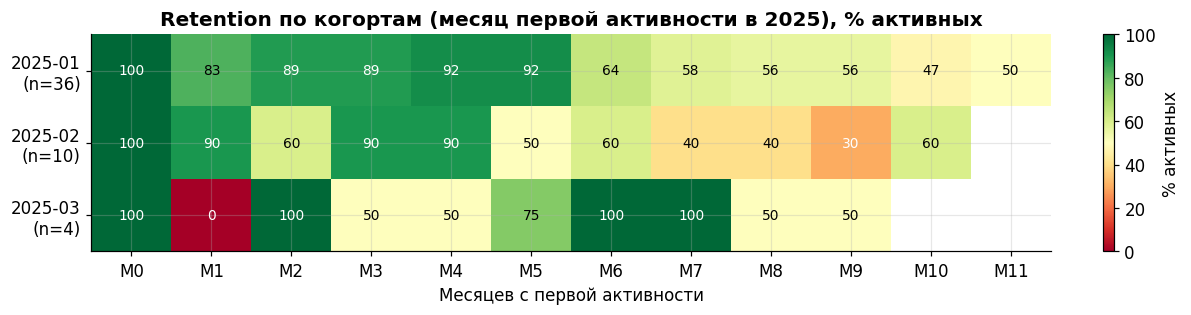

In [11]:
# 4. Retention по когортам, heatmap
fig, ax = plt.subplots(figsize=(11, 3))
M = retention[[c for c in retention.columns if c.startswith('M')]].astype(float)
im = ax.imshow(M.values, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(M.shape[1]))
ax.set_xticklabels(M.columns)
ax.set_yticks(range(len(M)))
ax.set_yticklabels([f'{i}\n(n={n})' for i, n in zip(retention.index, retention['клиентов'])])
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=9,
                    color='white' if v < 40 or v > 85 else 'black')
ax.set_title('Retention по когортам (месяц первой активности в 2025), % активных', fontweight='bold')
ax.set_xlabel('Месяцев с первой активности')
plt.colorbar(im, ax=ax, label='% активных', fraction=.025)
plt.tight_layout()
plt.savefig('charts/4_cohort_retention.png', bbox_inches='tight')
plt.show()

Для retention heatmap — привычный формат: цвет сразу показывает, где удержание высокое, а где падает.
Хорошо виден переход в жёлто-красное на шестом-седьмом месяце у главной январской когорты, то есть тот
же разрыв между полугодиями.

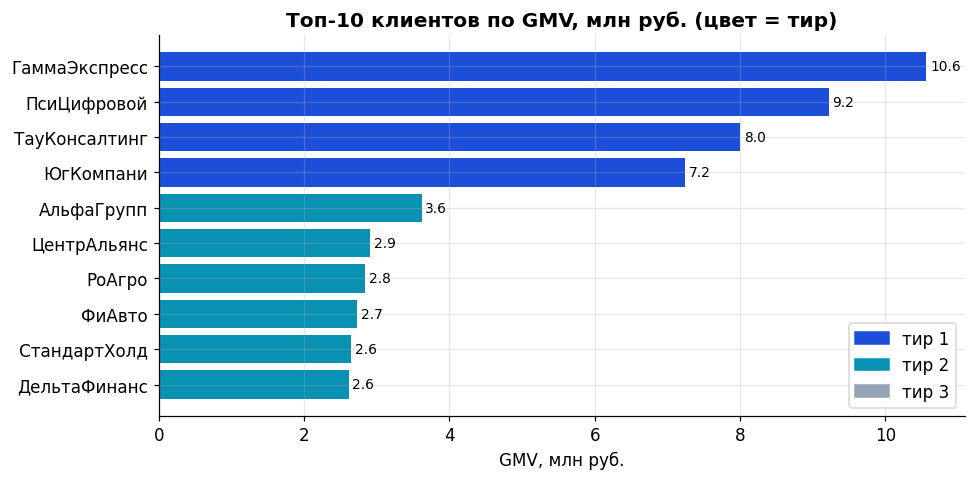

In [12]:
# 5. Топ-10 клиентов по GMV, цвет = тир
fig, ax = plt.subplots(figsize=(9, 4.5))
tier_col = {1: '#1d4ed8', 2: '#0891b2', 3: '#94a3b8'}
d = top10.reset_index().iloc[::-1]
ax.barh(d.company_name, d.gmv / 1e6, color=[tier_col[t] for t in d.tier])
for i, v in enumerate(d.gmv / 1e6):
    ax.text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)
ax.set_title('Топ-10 клиентов по GMV, млн руб. (цвет = тир)', fontweight='bold')
ax.set_xlabel('GMV, млн руб.')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=tier_col[t], label=f'тир {t}') for t in [1, 2, 3]], loc='lower right')
plt.tight_layout()
plt.savefig('charts/5_top10_clients.png', bbox_inches='tight')
plt.show()

Горизонтальные бары ранжируют клиентов по обороту, а цвет-тир показывает, что вся верхушка — это
тир 1. Наглядно связывает концентрацию GMV с сегментом.

## Задание 8. Ключевые выводы

**1. Оборот держится на avia + hotel и на нескольких крупных клиентах.**
- Что вижу: avia + hotel это 94% GMV; топ-10 клиентов дают 62%; 4 клиента тира 1 (8% базы) — 41% оборота.
- Почему важно: такая концентрация это риск. Уход одного крупного клиента стоит несколько миллионов оборота.
- Что дальше: завести отдельный мониторинг по клиентам тира 1 (частота, чек, отмены) с оповещением при спаде.

**2. Второе полугодие просело из-за оттока, а не из-за сезона.**
- Что вижу: GMV падает с 11.7 млн в июне до 4.2 млн в декабре; H1 = 49.9 против H2 = 34.8 млн. Причина — 16 клиентов, которые дали 17.5 млн в H1 и полностью пропали во втором полугодии.
- Почему важно: это не «низкий сезон», а потерянные клиенты, а значит проблема в принципе обратима.
- Что дальше: разобраться, что случилось на стыке июня–июля (закончились контракты? ушли к конкуренту?), запустить возврат ушедших и простую модель раннего предупреждения по падению частоты.

**3. Крупные клиенты и дороже, и активнее — часть гипотезы про «реже» не подтвердилась.**
- Что вижу: тир 1 — чек 82 тыс. и 107 бронирований на клиента; тир 3 — 29 тыс. и 14. GMV на клиента различается в 21 раз.
- Почему важно: вложения в поддержку и развитие крупных клиентов окупаются многократно, а по тиру 3 отдача низкая.
- Что дальше: попробовать программу роста тира 2 в тир 1 (у тира 2 уже 52 бронирования на клиента, потенциал есть), а для тира 3 сделать упор на дешёвый self-service.

**4. Avia отменяют чаще остальных, но горизонт брони тут ни при чём.**
- Что вижу: отмены avia 15.3% против 10.8% у taxi; при этом медианный горизонт брони везде одинаковый (~11 дней).
- Почему важно: avia самый дорогой продукт, каждая отмена дорого обходится.
- Что дальше: проверить, отменяется ли avia в связке со всей поездкой (avia + hotel), чтобы отделить отмену планов от смены билета; при подтверждении подумать о гибких тарифах и правилах перебронирования.
